In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
np.random.seed(42)

n = 1500

data = {
    "Age": np.random.randint(21, 60, n),
    "Department": np.random.choice(
        ["Sales", "IT", "HR", "Finance", "Marketing"],
        n
    ),
    "JobRole": np.random.choice(
        ["Developer", "Manager", "Analyst", "HR Executive",
         "Sales Executive", "Consultant"],
        n
    ),
    "MonthlyIncome": np.random.randint(25000, 150000, n),
    "JobSatisfaction": np.random.randint(1, 5, n),
    "EnvironmentSatisfaction": np.random.randint(1, 5, n),
    "WorkLifeBalance": np.random.randint(1, 5, n),
    "YearsAtCompany": np.random.randint(0, 20, n),
    "YearsInCurrentRole": np.random.randint(0, 12, n),
    "OverTime": np.random.choice(["Yes", "No"], n),
    "JobInvolvement": np.random.randint(1, 5, n),
    "PerformanceRating": np.random.randint(1, 5, n),
    "DistanceFromHome": np.random.randint(1, 40, n),
    "TrainingTimesLastYear": np.random.randint(0, 7, n),
    "NumCompaniesWorked": np.random.randint(0, 10, n)
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset created successfully!
Dataset Shape: (1500, 15)


,Age,Department,JobRole,MonthlyIncome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,OverTime,JobInvolvement,PerformanceRating,DistanceFromHome,TrainingTimesLastYear,NumCompaniesWorked
0,59,Finance,Sales Executive,50525,1,4,3,6,4,Yes,2,2,24,1,6
1,49,HR,Sales Executive,104818,3,4,2,4,2,No,3,3,15,2,9
2,35,Finance,Manager,139589,1,1,3,17,6,Yes,3,3,23,6,7
3,28,Sales,HR Executive,39334,1,2,4,1,6,No,3,1,4,3,0
4,41,Sales,Sales Executive,119715,4,3,3,10,1,No,4,2,38,1,9


In [5]:
# Create an attrition risk score based on HR-related factors

risk = (
    (df["OverTime"] == "Yes").astype(int) * 2
    + (df["JobSatisfaction"] <= 2).astype(int) * 2
    + (df["EnvironmentSatisfaction"] <= 2).astype(int)
    + (df["WorkLifeBalance"] <= 2).astype(int)
    + (df["YearsAtCompany"] <= 2).astype(int) * 2
    + (df["DistanceFromHome"] >= 25).astype(int)
    + (df["JobInvolvement"] <= 2).astype(int)
    + (df["NumCompaniesWorked"] >= 5).astype(int)
)

probability = 1 / (1 + np.exp(-(risk - 4)))

df["Attrition"] = np.random.binomial(1, probability)

df["Attrition"] = df["Attrition"].map({
    0: "No",
    1: "Yes"
})

print(df["Attrition"].value_counts())

df.head()

Attrition
Yes    914
No     586
Name: count, dtype: int64


,Age,Department,JobRole,MonthlyIncome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,OverTime,JobInvolvement,PerformanceRating,DistanceFromHome,TrainingTimesLastYear,NumCompaniesWorked,Attrition
0,59,Finance,Sales Executive,50525,1,4,3,6,4,Yes,2,2,24,1,6,Yes
1,49,HR,Sales Executive,104818,3,4,2,4,2,No,3,3,15,2,9,No
2,35,Finance,Manager,139589,1,1,3,17,6,Yes,3,3,23,6,7,Yes
3,28,Sales,HR Executive,39334,1,2,4,1,6,No,3,1,4,3,0,No
4,41,Sales,Sales Executive,119715,4,3,3,10,1,No,4,2,38,1,9,No


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Information:")
df.info()

Rows: 1500
Columns: 16

Missing Values:
Age                        0
Department                 0
JobRole                    0
MonthlyIncome              0
JobSatisfaction            0
EnvironmentSatisfaction    0
WorkLifeBalance            0
YearsAtCompany             0
YearsInCurrentRole         0
OverTime                   0
JobInvolvement             0
PerformanceRating          0
DistanceFromHome           0
TrainingTimesLastYear      0
NumCompaniesWorked         0
Attrition                  0
dtype: int64

Duplicate Rows:
0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1500 non-null   int64 
 1   Department               1500 non-null   object
 2   JobRole                  1500 non-null   object
 3   MonthlyIncome            1500 non-null   int64 
 4   JobSatisfact

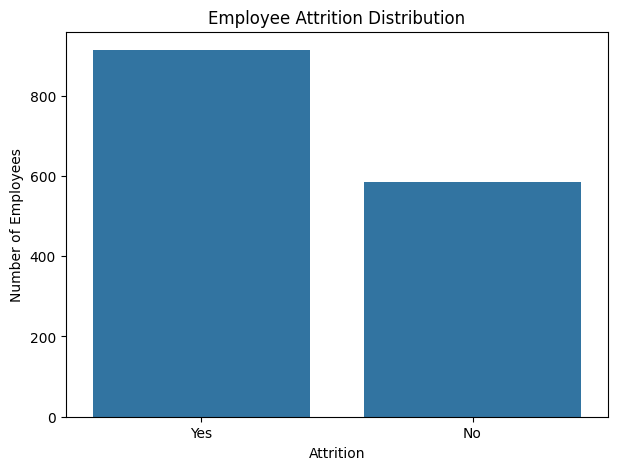

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [8]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition

Attrition,No,Yes
Department,,
Finance,35.029940,64.970060
HR,41.391941,58.608059
IT,42.068966,57.931034
Marketing,40.397351,59.602649
Sales,37.209302,62.790698


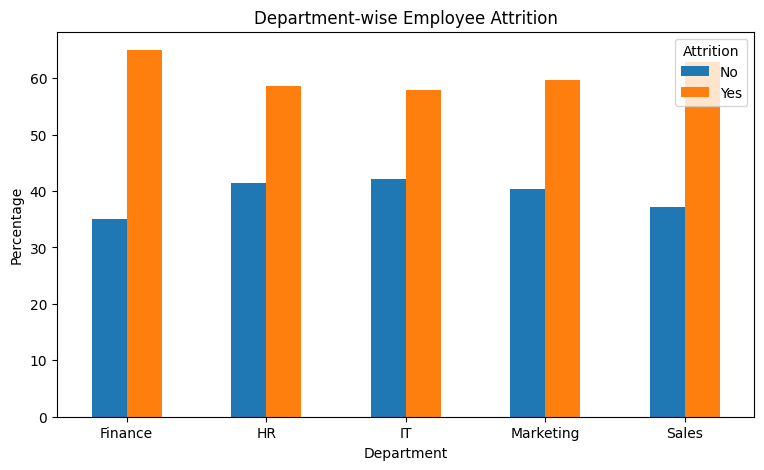

In [9]:
department_attrition.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Department-wise Employee Attrition")
plt.xlabel("Department")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Attrition")

plt.show()

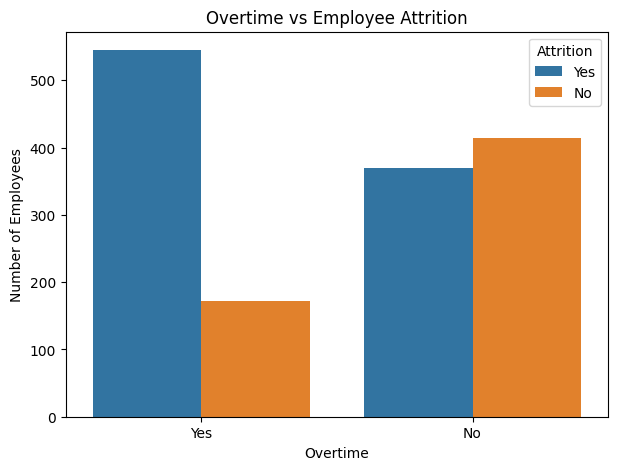

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Overtime vs Employee Attrition")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")

plt.show()

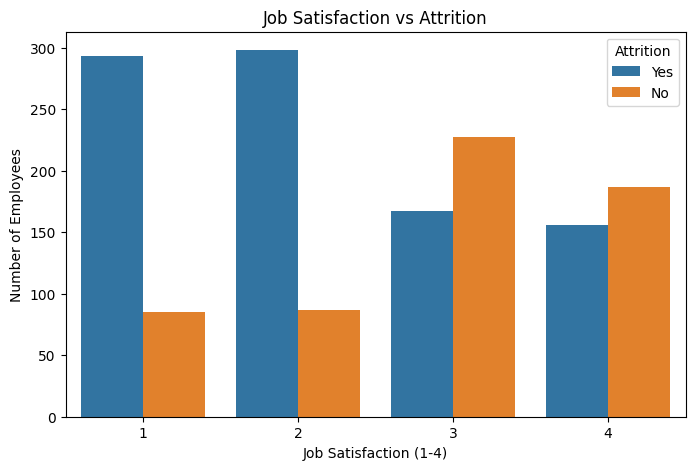

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction (1-4)")
plt.ylabel("Number of Employees")

plt.show()

In [12]:
model_df = df.copy()

# Encode categorical columns
encoder = LabelEncoder()

categorical_columns = [
    "Department",
    "JobRole",
    "OverTime"
]

for col in categorical_columns:
    model_df[col] = encoder.fit_transform(
        model_df[col]
    )

# Target encoding
model_df["Attrition"] = model_df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

X = model_df.drop("Attrition", axis=1)
y = model_df["Attrition"]

print("Features:", X.shape)
print("Target:", y.shape)

X.head()

Features: (1500, 15)
Target: (1500,)


,Age,Department,JobRole,MonthlyIncome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,OverTime,JobInvolvement,PerformanceRating,DistanceFromHome,TrainingTimesLastYear,NumCompaniesWorked
0,59,0,5,50525,1,4,3,6,4,1,2,2,24,1,6
1,49,1,5,104818,3,4,2,4,2,0,3,3,15,2,9
2,35,0,4,139589,1,1,3,17,6,1,3,3,23,6,7
3,28,4,3,39334,1,2,4,1,6,0,3,1,4,3,0
4,41,4,5,119715,4,3,3,10,1,0,4,2,38,1,9


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1200
Testing samples: 300


In [14]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [15]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy:",
      round(accuracy * 100, 2),
      "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Model Accuracy: 72.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.51      0.59       117
           1       0.73      0.85      0.79       183

    accuracy                           0.72       300
   macro avg       0.71      0.68      0.69       300
weighted avg       0.72      0.72      0.71       300



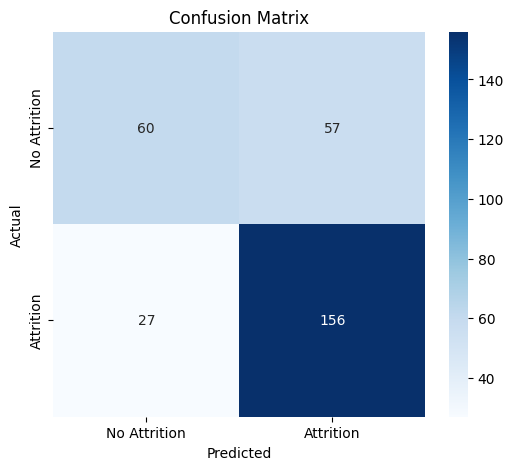

In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top Factors Affecting Employee Attrition:")

feature_importance.head(10)

Top Factors Affecting Employee Attrition:


,Feature,Importance
4,JobSatisfaction,0.120558
12,DistanceFromHome,0.100735
7,YearsAtCompany,0.094085
3,MonthlyIncome,0.091410
9,OverTime,0.079310
0,Age,0.076668
14,NumCompaniesWorked,0.067080
8,YearsInCurrentRole,0.061772
10,JobInvolvement,0.054030
13,TrainingTimesLastYear,0.049191


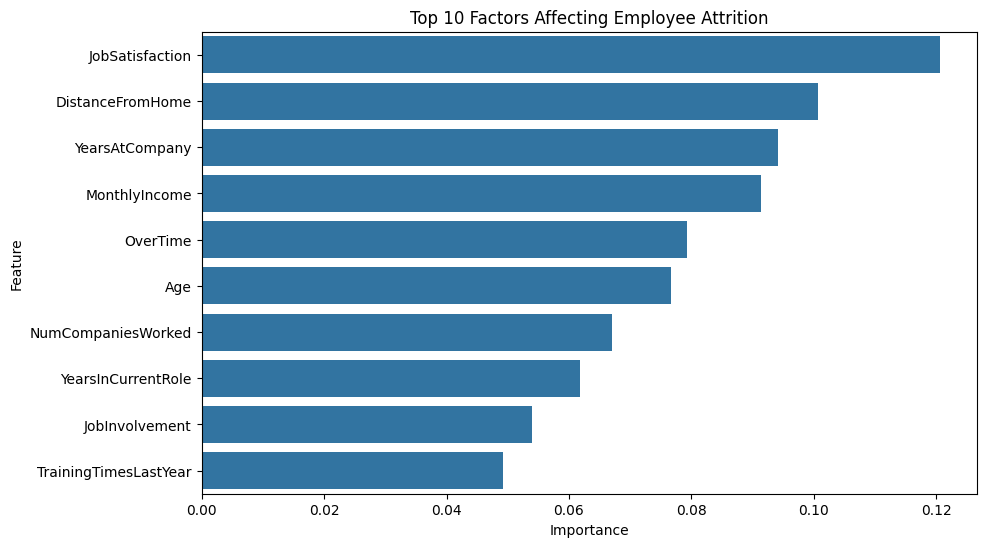

In [18]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Factors Affecting Employee Attrition")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [19]:
# Probability that employee may leave

risk_probability = model.predict_proba(X_test)[:, 1]

risk_score = risk_probability * 100

risk_category = []

for score in risk_score:

    if score < 30:
        risk_category.append("Low Risk")

    elif score < 60:
        risk_category.append("Medium Risk")

    else:
        risk_category.append("High Risk")


risk_results = X_test.copy()

risk_results["Actual_Attrition"] = y_test.values

risk_results["Risk_Score"] = np.round(
    risk_score,
    2
)

risk_results["Risk_Category"] = risk_category

risk_results.head(15)

,Age,Department,JobRole,MonthlyIncome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,OverTime,JobInvolvement,PerformanceRating,DistanceFromHome,TrainingTimesLastYear,NumCompaniesWorked,Actual_Attrition,Risk_Score,Risk_Category
334,54,2,1,59700,3,4,4,8,11,0,2,4,10,4,0,0,33.5,Medium Risk
1468,49,1,0,43624,3,2,4,6,6,0,4,4,17,4,5,0,17.0,Low Risk
1232,34,3,0,115417,4,3,1,16,3,1,2,1,17,6,0,1,61.5,High Risk
1041,24,4,0,30695,3,4,1,5,0,0,1,1,38,2,4,1,59.0,Medium Risk
262,23,1,2,59057,2,4,1,9,11,0,2,3,11,6,7,1,71.5,High Risk
898,53,4,0,105072,1,2,1,2,1,0,2,4,18,3,9,1,87.5,High Risk
1202,32,1,1,125766,2,3,1,14,7,0,4,4,16,3,9,1,44.5,Medium Risk
148,47,1,1,50517,3,3,1,19,9,0,2,2,23,6,0,0,42.0,Medium Risk
989,30,2,3,139912,1,2,3,10,11,0,4,2,34,1,1,0,84.0,High Risk
287,49,3,3,95744,2,2,4,1,11,0,2,2,1,0,0,1,74.5,High Risk


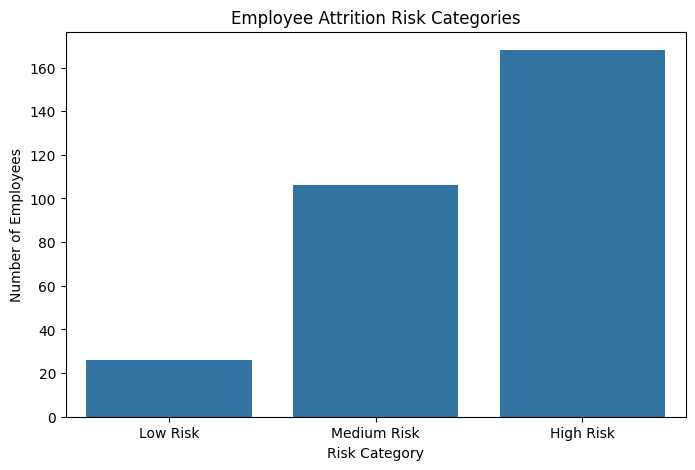

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=risk_results,
    x="Risk_Category",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Employee Attrition Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Employees")

plt.show()

In [21]:
high_risk = risk_results[
    risk_results["Risk_Category"] == "High Risk"
].sort_values(
    by="Risk_Score",
    ascending=False
)

print(
    "Number of High-Risk Employees:",
    len(high_risk)
)

high_risk.head(20)

Number of High-Risk Employees: 168


,Age,Department,JobRole,MonthlyIncome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,OverTime,JobInvolvement,PerformanceRating,DistanceFromHome,TrainingTimesLastYear,NumCompaniesWorked,Actual_Attrition,Risk_Score,Risk_Category
314,53,3,0,90982,1,2,1,6,8,1,2,4,34,2,9,1,94.5,High Risk
360,48,2,4,100485,1,1,2,4,5,0,1,2,19,4,7,1,94.0,High Risk
1098,22,3,2,50095,2,1,2,2,9,1,2,1,36,6,8,1,94.0,High Risk
117,35,2,0,81541,1,3,1,8,5,1,1,1,32,5,7,1,93.5,High Risk
405,51,4,0,35878,1,3,2,8,7,1,2,2,28,3,8,1,92.0,High Risk
127,59,3,2,50380,2,1,2,1,1,1,2,2,19,3,7,1,91.5,High Risk
1313,28,0,1,115633,2,2,3,1,8,0,2,3,27,5,9,1,91.0,High Risk
850,40,3,5,100426,1,3,2,7,6,1,4,2,30,5,9,1,91.0,High Risk
475,40,2,3,72574,1,3,1,4,6,1,2,1,26,5,5,1,90.0,High Risk
1486,26,0,4,117868,1,4,1,0,4,1,4,2,25,4,9,1,90.0,High Risk


In [22]:
df.to_csv(
    "Employee_Attrition_Dataset.csv",
    index=False
)

risk_results.to_csv(
    "Employee_Attrition_Risk_Results.csv",
    index=False
)

print("Both files saved successfully!")

Both files saved successfully!


In [23]:
from google.colab import files

files.download(
    "Employee_Attrition_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
files.download(
    "Employee_Attrition_Risk_Results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
print("""
=========================================
PROJECT CONCLUSION
=========================================

The Employee Attrition Prediction and Risk
Scoring System was developed using Machine
Learning.

A synthetic HR employee dataset containing
1500 employee records was created for this
project.

Random Forest Classification was used to
predict employee attrition.

The system also generates an individual
employee Risk Score and classifies employees
into:

1. Low Risk
2. Medium Risk
3. High Risk

The analysis helps identify important factors
associated with employee attrition such as
overtime, job satisfaction, work-life balance,
years at company and distance from home.

This system can support HR teams in identifying
employees who may require retention-focused
interventions.
=========================================
""")


PROJECT CONCLUSION

The Employee Attrition Prediction and Risk
Scoring System was developed using Machine
Learning.

A synthetic HR employee dataset containing
1500 employee records was created for this
project.

Random Forest Classification was used to
predict employee attrition.

The system also generates an individual
employee Risk Score and classifies employees
into:

1. Low Risk
2. Medium Risk
3. High Risk

The analysis helps identify important factors
associated with employee attrition such as
overtime, job satisfaction, work-life balance,
years at company and distance from home.

This system can support HR teams in identifying
employees who may require retention-focused
interventions.

